# LinkedIn Job Postings (2023 - 2024)

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import re
import nltk
import spacy 
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

In [3]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to C:\Users\Lenovo
[nltk_data]     T450\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Lenovo
[nltk_data]     T450\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Importación y exploración de los post

In [4]:
post = pd.read_csv("data/postings.csv")

In [5]:
post.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [6]:
post.info()

<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  str    
 2   title                       123849 non-null  str    
 3   description                 123842 non-null  str    
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   str    
 6   location                    123849 non-null  str    
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  str    
 12  applies                     23320 non-null   float64
 13  original_listed_time     

Primero vamos a filtrar las ofertas con el título "Data Analyst" en el csv, vamos a encontrar las vacantes con esta palabra.

In [7]:
post_data_analyst = post[post.title.str.contains('data analyst', case = False, na = False )]

In [8]:
post_data_analyst.info()

<class 'pandas.DataFrame'>
Index: 408 entries, 389 to 122747
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      408 non-null    int64  
 1   company_name                406 non-null    str    
 2   title                       408 non-null    str    
 3   description                 408 non-null    str    
 4   max_salary                  113 non-null    float64
 5   pay_period                  130 non-null    str    
 6   location                    408 non-null    str    
 7   company_id                  406 non-null    float64
 8   views                       402 non-null    float64
 9   med_salary                  17 non-null     float64
 10  min_salary                  113 non-null    float64
 11  formatted_work_type         408 non-null    str    
 12  applies                     251 non-null    float64
 13  original_listed_time        408 non-null    fl

In [9]:
post_data_analyst.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
389,3813645405,Tenazx Inc,Data Analyst,Job Title: Data AnalystDuration: ContractLocat...,NaN,NaN,"Queens, NY",82537206.0,4.0,NaN,...,NaN,1.713465e+12,NaN,0,CONTRACT,NaN,NaN,NaN,11427.0,36081.0
670,3872787865,Radiant Systems Inc,eCommerce Data Analyst,Job Description: JOB SUMMARY:Responsible for c...,NaN,NaN,United States,3342169.0,102.0,NaN,...,NaN,1.713278e+12,NaN,0,CONTRACT,NaN,NaN,NaN,NaN,NaN
1044,3884432522,MCubeSoft,Wealth Management Business Data Analyst,Job Title: BUSINESS DATA ANALYST Location: Aus...,NaN,NaN,"Charlotte, NC",74604183.0,8.0,NaN,...,NaN,1.712346e+12,NaN,0,FULL_TIME,NaN,NaN,NaN,28202.0,37119.0
1277,3884434978,Outlier,"Senior Data Analyst - AI Training (Remote, Con...",Job Type: Contract\n\nWe don’t sponsor work vi...,NaN,HOURLY,United States,92583550.0,258.0,55.0,...,NaN,1.712350e+12,boards.greenhouse.io,0,CONTRACT,USD,BASE_SALARY,114400.0,NaN,NaN
1755,3884438958,USCTEK - Recruiting & Staffing,Onsite Data Analyst || USC ONLY || FL LOCALS,Position: Sr. Data AnalystDuration: Long TermL...,NaN,NaN,"Jacksonville, FL",13637042.0,44.0,NaN,...,NaN,1.712351e+12,NaN,0,CONTRACT,NaN,NaN,NaN,32099.0,12031.0


Ahora que tenemos a las vacantes filtradas, vamos a unirlas con las job skills

In [10]:
# Exportamos los csv's correspondientes a las habilidades tanto a las abreviaciones como su significado
job_skills = pd.read_csv("data/jobs/job_skills.csv")
skills = pd.read_csv('data/mappings/skills.csv')
job_industries = pd.read_csv('data/jobs/job_industries.csv')
industries = pd.read_csv('data/mappings/industries.csv')
salaries = pd.read_csv('data/jobs/salaries.csv')

In [11]:
post_data_analyst = pd.merge(pd.merge(post_data_analyst, job_skills, on='job_id'), skills, on='skill_abr')
post_data_analyst = pd.merge(pd.merge(post_data_analyst,job_industries, on='job_id'),industries, on='industry_id')
post_data_analyst = pd.merge(post_data_analyst, salaries, on= 'job_id')

In [ ]:
post_data_analyst = post_data_analyst[['job_id', 'company_name', 'title', 'description','location', 'company_id', 'views','applies','remote_allowed', 'formatted_experience_level','work_type', 'skill_name', 'industry_name']]

Vamos a ver ahora si tenemos posts repetidos

In [13]:
post_data_analyst[post_data_analyst['job_id'].duplicated(keep=False)]

,job_id,company_name,title,description,location,company_id,views,applies,remote_allowed,formatted_experience_level,skills_desc,work_type,skill_name,industry_name
1,3884441553,OpTech,Data Analyst - Expert with Excel,Why work at OpTech? OpTech is a woman-owned co...,"Auburn Hills, MI",2425438.0,186.0,72.0,NaN,Mid-Senior level,NaN,CONTRACT,Information Technology,Banking
2,3884441553,OpTech,Data Analyst - Expert with Excel,Why work at OpTech? OpTech is a woman-owned co...,"Auburn Hills, MI",2425438.0,186.0,72.0,NaN,Mid-Senior level,NaN,CONTRACT,Information Technology,IT Services and IT Consulting
3,3884819737,Acro Service Corp,Data Analyst,"Must be a US citizen or GC holder, Local to Or...","Orlando, FL",50861.0,143.0,44.0,NaN,Mid-Senior level,NaN,CONTRACT,Information Technology,Government Administration
4,3884819737,Acro Service Corp,Data Analyst,"Must be a US citizen or GC holder, Local to Or...","Orlando, FL",50861.0,143.0,44.0,NaN,Mid-Senior level,NaN,CONTRACT,Information Technology,Information Services
5,3884822884,Stanford University,Research Data Analyst 1 (75% FTE/Hybrid Opport...,The Department of Psychiatry and Behavioral Sc...,"Stanford, CA",1792.0,12.0,1.0,NaN,Mid-Senior level,NaN,PART_TIME,Research,Higher Education
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,3905842941,Solü Technology Partners,Sr Data Analyst,"Title: Sr Data Analyst \nLocation: Phoenix, Az...","Phoenix, AZ",2587248.0,2.0,NaN,NaN,Mid-Senior level,NaN,CONTRACT,Engineering,"Technology, Information and Media"
253,3905842941,Solü Technology Partners,Sr Data Analyst,"Title: Sr Data Analyst \nLocation: Phoenix, Az...","Phoenix, AZ",2587248.0,2.0,NaN,NaN,Mid-Senior level,NaN,CONTRACT,Information Technology,Public Policy Offices
254,3905842941,Solü Technology Partners,Sr Data Analyst,"Title: Sr Data Analyst \nLocation: Phoenix, Az...","Phoenix, AZ",2587248.0,2.0,NaN,NaN,Mid-Senior level,NaN,CONTRACT,Information Technology,"Technology, Information and Media"
257,3905860739,Revolution Technologies,Master Data Analyst,NO C2C or supplier resumes please.\nThe schedu...,"Creve Coeur, MO",36676.0,2.0,NaN,NaN,Entry level,NaN,CONTRACT,Information Technology,Biotechnology Research


Procederemos a eliminar los registros repetidos

In [14]:
post_data_analyst = post_data_analyst.drop_duplicates(subset=['job_id'], keep='first')

In [15]:
post_data_analyst.info()

<class 'pandas.DataFrame'>
Index: 128 entries, 0 to 266
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      128 non-null    int64  
 1   company_name                128 non-null    str    
 2   title                       128 non-null    str    
 3   description                 128 non-null    str    
 4   location                    128 non-null    str    
 5   company_id                  128 non-null    float64
 6   views                       125 non-null    float64
 7   applies                     79 non-null     float64
 8   remote_allowed              40 non-null     float64
 9   formatted_experience_level  109 non-null    str    
 10  skills_desc                 0 non-null      str    
 11  work_type                   128 non-null    str    
 12  skill_name                  128 non-null    str    
 13  industry_name               128 non-null    str    

Podemos observar que tenemos ahora un total de 128 filas, en estas procedermos ver las skills que más se repiten

In [16]:
skills_count = post_data_analyst.skill_name.value_counts().head(10)

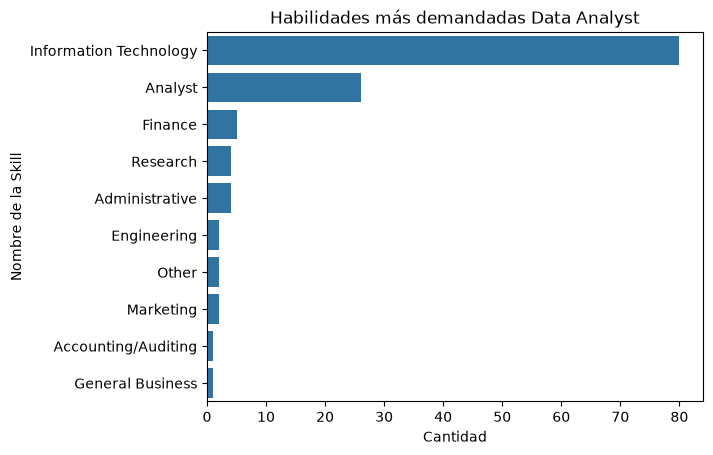

In [17]:
sns.barplot(x=skills_count.values, y=skills_count.index)
plt.title("Habilidades más demandadas Data Analyst")
plt.xlabel("Cantidad")
plt.ylabel('Nombre de la Skill')
plt.show()

Además vamos a ver cuales que tecnologías son más solicitadas en cada post, principalmente nos concentraremos en Excel, SQL, Python, R.

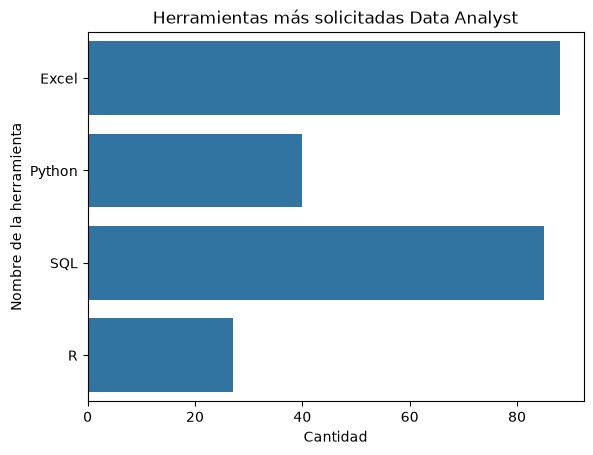

In [18]:
# Conteo de las tecnologias

tools_da = {'Excel': 0, 'Python': 0, 'SQL': 0, 'R': 0}
for tool in tools_da.keys():
    patron = rf'\b{tool.strip()}\b' if tool.strip() == 'R' else tool.strip()
    conteo = int(post_data_analyst['description'].str.contains(patron, case=False, na=False).sum())
    tools_da[tool] = conteo

# Creación del DataFrame

tools_data_analyst = pd.DataFrame.from_dict(tools_da, orient='index', columns=['count'])

# Gráfica

sns.barplot(x=tools_data_analyst['count'], y=tools_data_analyst.index)
plt.title("Herramientas más solicitadas Data Analyst")
plt.xlabel("Cantidad")
plt.ylabel('Nombre de la herramienta')
plt.show()

Vamos ahora a hacer un analisis similar pero para los post de las ofertas de "Data Scientist"

In [ ]:
#Filtramos los post de Data Science
post_data_scientist = post[post.title.str.contains('data scient', case = False, na = False )]

# Unimos los otros csv para hacer el análsis
post_data_scientist = pd.merge(pd.merge(post_data_scientist, job_skills, on='job_id'), skills, on='skill_abr')
post_data_scientist = pd.merge(pd.merge(post_data_scientist,job_industries, on='job_id'),industries, on='industry_id')
post_data_scientist = pd.merge(post_data_scientist, salaries, on= 'job_id')

#Nos quedamos con las columnas que nos interesan
post_data_scientist = post_data_scientist[['job_id', 'company_name', 'title', 'description','location', 'company_id', 'views','applies','remote_allowed', 'formatted_experience_level','work_type', 'skill_name', 'industry_name']]

#Eliminamos las filas duplicadas
post_data_scientist = post_data_scientist.drop_duplicates(subset=['job_id'], keep='first')

In [20]:
post_data_scientist.info()

<class 'pandas.DataFrame'>
Index: 89 entries, 0 to 244
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      89 non-null     int64  
 1   company_name                89 non-null     str    
 2   title                       89 non-null     str    
 3   description                 89 non-null     str    
 4   location                    89 non-null     str    
 5   company_id                  89 non-null     float64
 6   views                       89 non-null     float64
 7   applies                     47 non-null     float64
 8   remote_allowed              32 non-null     float64
 9   formatted_experience_level  73 non-null     str    
 10  skills_desc                 0 non-null      str    
 11  work_type                   89 non-null     str    
 12  skill_name                  89 non-null     str    
 13  industry_name               89 non-null     str    


In [21]:
skills_count_scient = post_data_scientist.skill_name.value_counts().head(10)

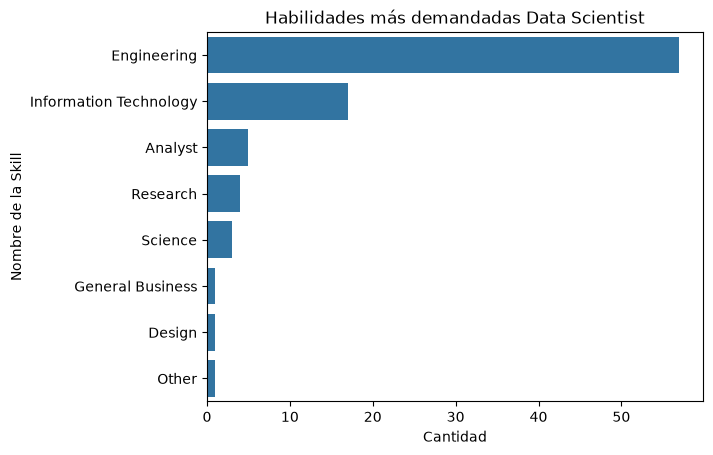

In [22]:
sns.barplot(x=skills_count_scient.values, y=skills_count_scient.index)
plt.title("Habilidades más demandadas Data Scientist")
plt.xlabel("Cantidad")
plt.ylabel('Nombre de la Skill')
plt.show()

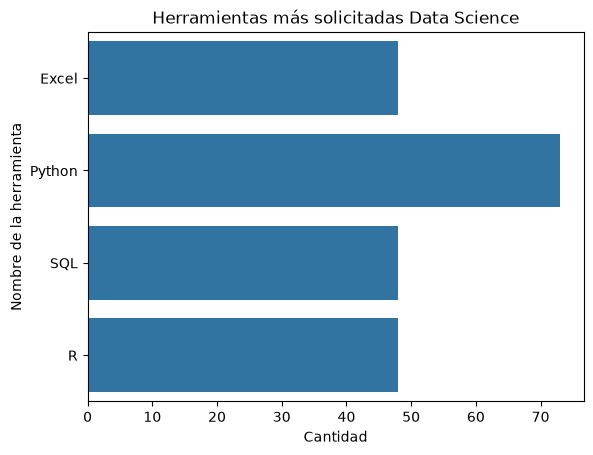

In [23]:
# Conteo de las tecnologias

tools_ds = {'Excel': 0, 'Python': 0, 'SQL': 0, 'R': 0}
for tool in tools_ds.keys():
    patron = rf'\b{tool.strip()}\b' if tool.strip() == 'R' else tool.strip()
    conteo = int(post_data_scientist['description'].str.contains(patron, case=False, na=False).sum())
    tools_ds[tool] = conteo

# Creación del DataFrame

tools_data_science = pd.DataFrame.from_dict(tools_ds, orient='index', columns=['count'])

# Gráfica

sns.barplot(x=tools_data_science['count'], y=tools_data_science.index)
plt.title("Herramientas más solicitadas Data Science")
plt.xlabel("Cantidad")
plt.ylabel('Nombre de la herramienta')
plt.show()

# Analisis de las descripciones de cada post

In [24]:
# Definir la Stopwords
stopwords = set(nltk.corpus.stopwords.words('english')) 
nlp = spacy.load("en_core_web_sm")

#Limpieza de los posts
def post_cleaner(text):
    # Primero pasamos todas las letras a minúsculas
    text = text.lower()
    # Eliminamos los caracteres inecesarios
    patron = r'[^\w\s]'
    text = re.sub(patron, ' ', text)
    return text
 
#Eliminar las Stop Word
def stop_tok_lem(text):
    #Primero tokenizamos
    tok = word_tokenize(text)
    stop = [word for word in tok if word.isalnum() and word not in stopwords]
    text = ' '.join(stop)
    #doc = nlp(text)
    #lem = [token.lemma_ for token in doc]
    #text = ' '.join(lem)
    return text


In [25]:
# Procedemos a aplicar las funciones sobre la descrpción de cada post
post_data_analyst['desc_clean'] = post_data_analyst['description'].apply(post_cleaner)
post_data_analyst['desc_clean'] = post_data_analyst['desc_clean'].apply(stop_tok_lem)

# Juntamos todos los posts para crear la nube

texto_para_nube = ' '.join(post_data_analyst['desc_clean'])

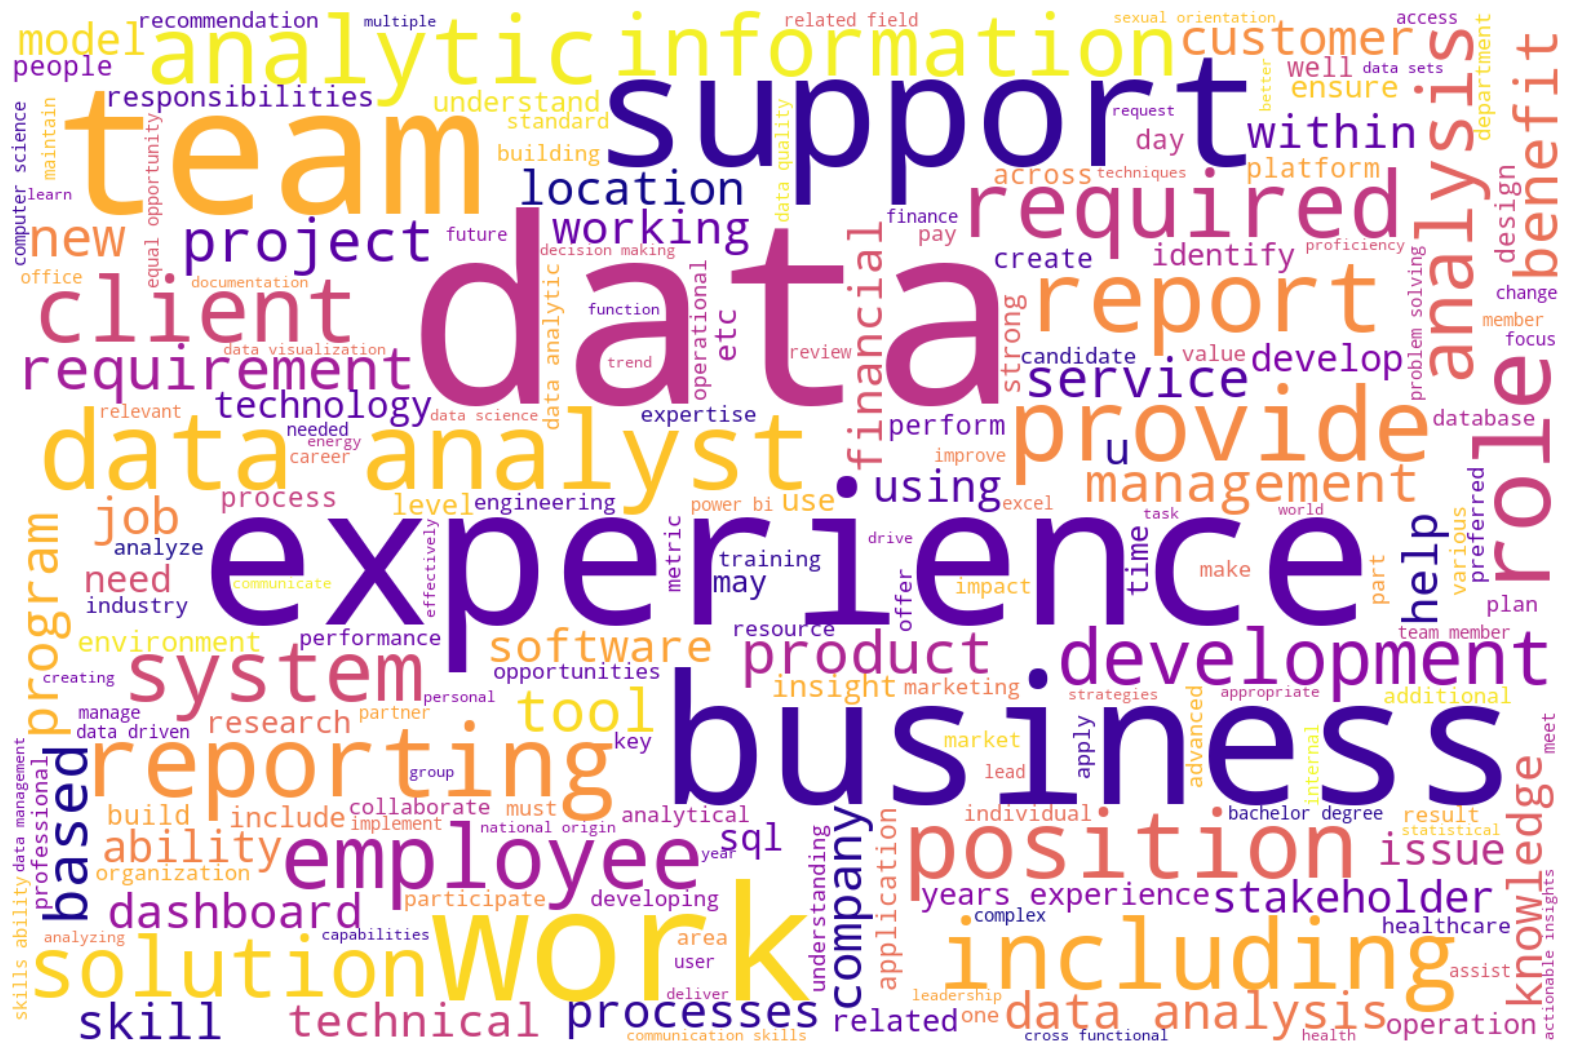

In [26]:
nube = WordCloud(
    width=1200, 
    height=800,
    background_color='white',       
    colormap='plasma',              
    max_words=200,                  
    max_font_size=200,              
    prefer_horizontal=0.85 ).generate(texto_para_nube)

plt.figure(figsize=(20,20))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.show()

Vamos a hacer lo mismo para los post de Data Scientist

In [27]:
# Procedemos a aplicar las funciones sobre la descrpción de cada post
post_data_scientist['desc_clean'] = post_data_scientist['description'].apply(post_cleaner)
post_data_scientist['desc_clean'] = post_data_scientist['desc_clean'].apply(stop_tok_lem)

# Juntamos todos los posts para crear la nube

texto_para_nube2 = ' '.join(post_data_scientist['desc_clean'])

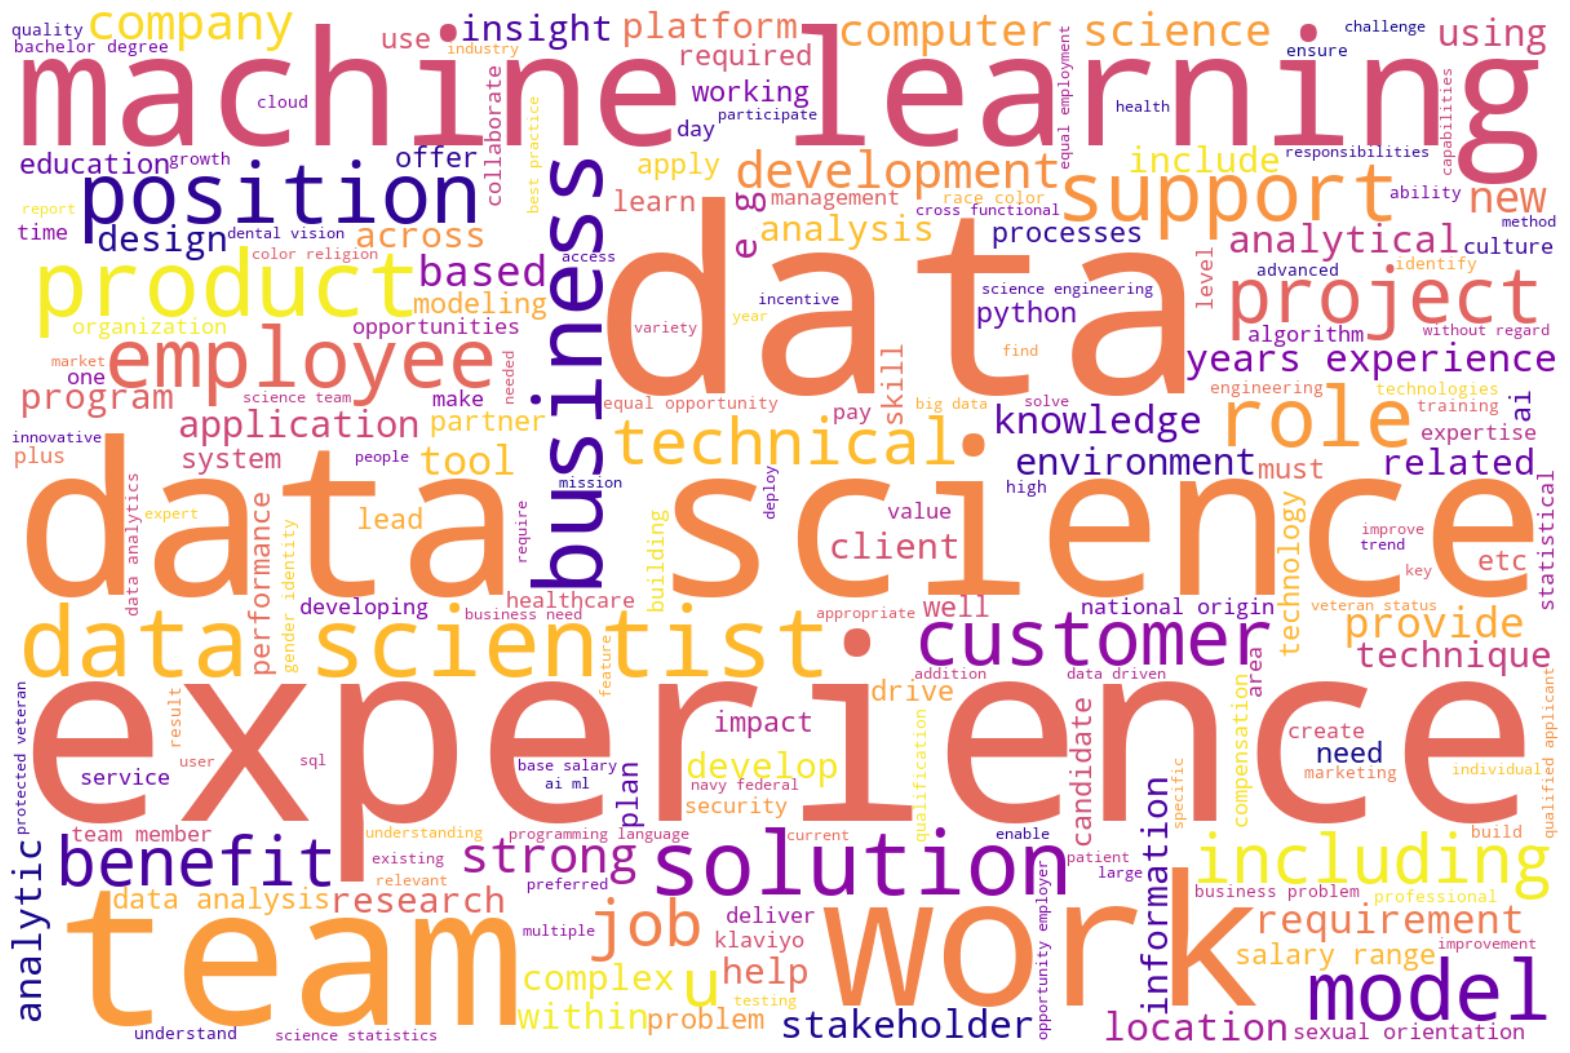

In [28]:
nube2 = WordCloud(
    width=1200, 
    height=800,
    background_color='white',       
    colormap='plasma',              
    max_words=200,                  
    max_font_size=200,              
    prefer_horizontal=0.85 ).generate(texto_para_nube2)

plt.figure(figsize=(20,20))
plt.imshow(nube2, interpolation="bilinear")
plt.axis("off")
plt.show()

Vamos ahora analizar a las industrias que publican estos posts. Para esto vamos a ver cuales son las 10 industrias que más se repiten.

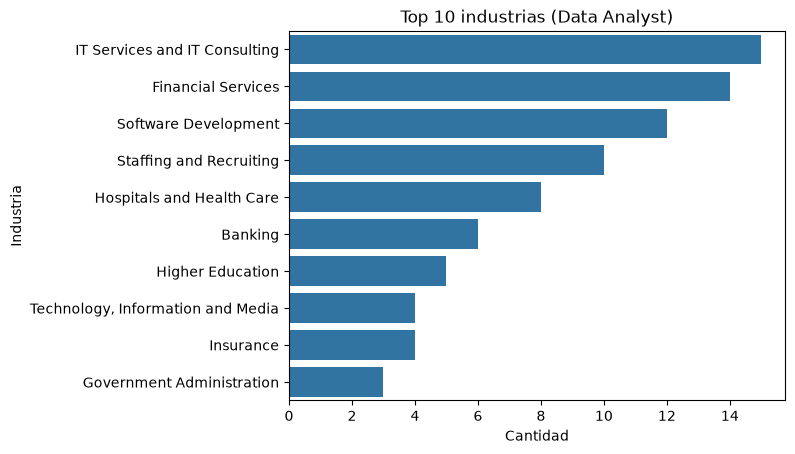

In [35]:
top_10_industries_da = post_data_analyst['industry_name'].value_counts().head(10)
sns.barplot(x=top_10_industries_da.values, y=top_10_industries_da.index)
plt.title("Top 10 industrias (Data Analyst)")
plt.xlabel("Cantidad")
plt.ylabel('Industria')
plt.show()

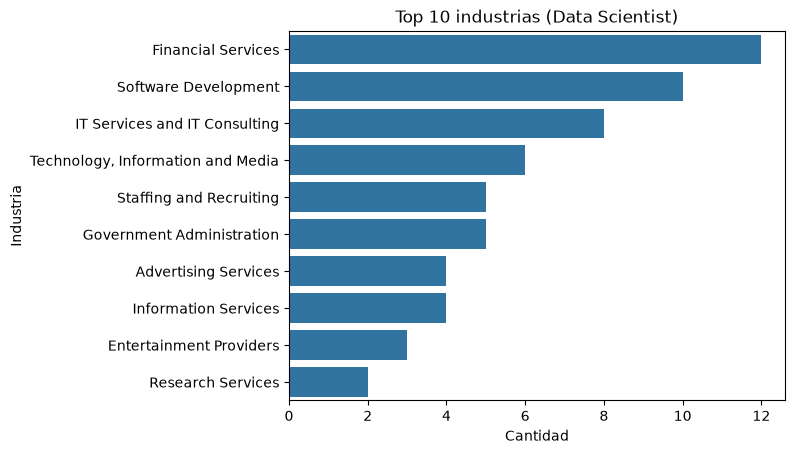

In [39]:
top_10_industries_ds = post_data_scientist['industry_name'].value_counts().head(10)
sns.barplot(x=top_10_industries_ds.values, y=top_10_industries_ds.index)
plt.title("Top 10 industrias (Data Scientist)")
plt.xlabel("Cantidad")
plt.ylabel('Industria')
plt.show()